In [27]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.utils as vutils

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [28]:


# ----------------------------
# Encoder Network
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# ----------------------------
# Decoder Network (Learned Variance)
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv_base = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),  # 14x14 -> 28x28
            nn.ReLU()
        )

        # Two output heads:
        self.out_mu = nn.Conv2d(32, 1, kernel_size=3, padding=1)       # Mean image
        self.out_logvar = nn.Conv2d(32, 1, kernel_size=3, padding=1)   # Log-variance

    def forward(self, z):
        x = self.fc(z).view(-1, 64, 7, 7)
        x = self.deconv_base(x)
        mu = torch.sigmoid(self.out_mu(x))  # constrain to [0,1] pixel space
        logvar = self.out_logvar(x)         # unconstrained
        logvar = torch.clamp(logvar, min=-6.0, max=3.0)  # Clamp safely here
        return mu, logvar

# ----------------------------
# VAE Wrapper
# ----------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu_z, logvar_z = self.encoder(x)                 # encoder outputs
        z = self.reparameterize(mu_z, logvar_z)          # latent sample
        mu_x, logvar_x = self.decoder(z)                 # decoder outputs
        return mu_x, logvar_x, mu_z, logvar_z, z         # outputs needed for ELBO

In [29]:


def get_mnist_dataloaders(batch_size=128):
    transform = transforms.Compose([transforms.ToTensor()])
    full_train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
    train_set, val_set = random_split(full_train_set, [50000, 10000])
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True),
        DataLoader(val_set, batch_size=batch_size, shuffle=False),
        DataLoader(test_set, batch_size=batch_size, shuffle=False)
    )

def elbo_loss(x, mu_x, logvar_x, mu_z, logvar_z):
    B = x.size(0)
    x = x.view(B, -1)
    mu_x = mu_x.view(B, -1)
    logvar_x = logvar_x.view(B, -1)

    eps = 1e-6
    var = torch.exp(logvar_x) + eps  # Safe variance

    # Numerically stable Gaussian log-likelihood
    recon_loss = 0.5 * (
        torch.log(2 * torch.pi * var) + ((x - mu_x) ** 2) / var
    )
    recon_loss = torch.sum(recon_loss, dim=1)

    # KL divergence
    kl_div = -0.5 * torch.sum(1 + logvar_z - mu_z.pow(2) - logvar_z.exp(), dim=1)

    return torch.mean(recon_loss + kl_div)

In [30]:

def train_vae(model, train_loader, val_loader, optimizer,
                                   num_epochs=100, patience=10, device='cuda'):

    model = model.to(device)
    train_elbo, val_elbo = [], []

    best_val_elbo = float('-inf')
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()
            mu_x, logvar_x, mu_z, logvar_z, _ = model(x_batch)
            loss = elbo_loss(x_batch, mu_x, logvar_x, mu_z, logvar_z)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_elbo.append(-avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_val, _ in val_loader:
                x_val = x_val.to(device)
                mu_x, logvar_x, mu_z, logvar_z, _ = model(x_val)
                loss = elbo_loss(x_val, mu_x, logvar_x, mu_z, logvar_z)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_elbo.append(-avg_val_loss)

        print(f"Epoch {epoch:02d} | Train ELBO: {-avg_train_loss:.4f} | Val ELBO: {-avg_val_loss:.4f}")

        # Early stopping logic
        if -avg_val_loss > best_val_elbo:
            best_val_elbo = -avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict()
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch} due to no improvement in validation ELBO.")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Plot ELBO
    plt.plot(train_elbo, label='Train ELBO')
    plt.plot(val_elbo, label='Validation ELBO')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO')
    plt.legend()
    plt.title('ELBO vs Epoch')
    plt.show()

    return train_elbo, val_elbo



In [31]:

def test_vae_reconstruction_and_generation(model, test_loader, device='cuda'):
    model.eval()
    model = model.to(device)

    # Get a single batch from test set
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:32].to(device)  # use only first 32 for display
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x_test)
        z = model.reparameterize(mu_z, logvar_z)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        recon_x = mu_x + std_x * torch.randn_like(std_x)  # sample x' ~ N(mu, sigma²)

    # Arrange originals and reconstructions side-by-side
    grid = torch.cat([x_test.cpu(), recon_x.cpu()], dim=0)
    grid_img = vutils.make_grid(grid, nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Top: Original | Bottom: Reconstruction')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

def generate_from_prior(model, num_samples=64, device='cuda'):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
        z = torch.randn(num_samples, model.encoder.fc_mu.out_features).to(device)
        mu_x, logvar_x = model.decoder(z)
        std_x = torch.exp(0.5 * logvar_x)
        gen_x = mu_x + std_x * torch.randn_like(std_x)

    grid_img = vutils.make_grid(gen_x.cpu(), nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Generated Samples from Prior')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()


Epoch 01 | Train ELBO: 250.8420 | Val ELBO: 819.2587
Epoch 02 | Train ELBO: 927.2282 | Val ELBO: 1014.5658
Epoch 03 | Train ELBO: 1067.7646 | Val ELBO: 1105.4944
Epoch 04 | Train ELBO: 1128.1053 | Val ELBO: 1147.0815
Epoch 05 | Train ELBO: 1160.1963 | Val ELBO: 1171.0745
Epoch 06 | Train ELBO: 1181.7312 | Val ELBO: 1190.3400
Epoch 07 | Train ELBO: 1198.7119 | Val ELBO: 1205.5990
Epoch 08 | Train ELBO: 1212.6331 | Val ELBO: 1217.4869
Epoch 09 | Train ELBO: 1223.7664 | Val ELBO: 1228.0525
Epoch 10 | Train ELBO: 1232.9983 | Val ELBO: 1234.5114
Epoch 11 | Train ELBO: 1240.4999 | Val ELBO: 1242.4896
Epoch 12 | Train ELBO: 1246.8864 | Val ELBO: 1247.5324
Epoch 13 | Train ELBO: 1252.5645 | Val ELBO: 1253.1311
Epoch 14 | Train ELBO: 1257.1223 | Val ELBO: 1257.1115
Epoch 15 | Train ELBO: 1261.6483 | Val ELBO: 1260.6566
Epoch 16 | Train ELBO: 1265.4551 | Val ELBO: 1259.6366
Epoch 17 | Train ELBO: 1268.5672 | Val ELBO: 1266.4279
Epoch 18 | Train ELBO: 1271.8961 | Val ELBO: 1269.5928
Epoch 19 | Tr

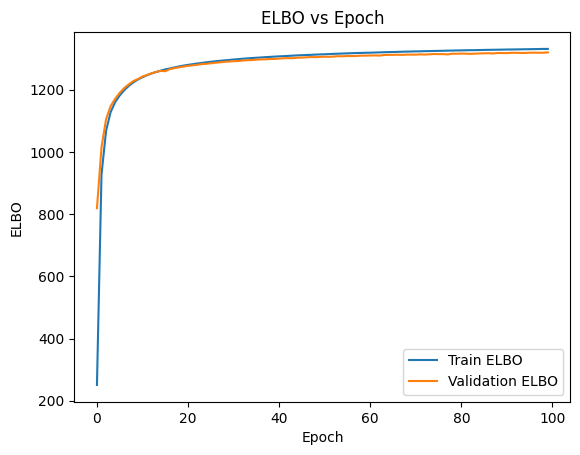

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5783912..1.5865208].


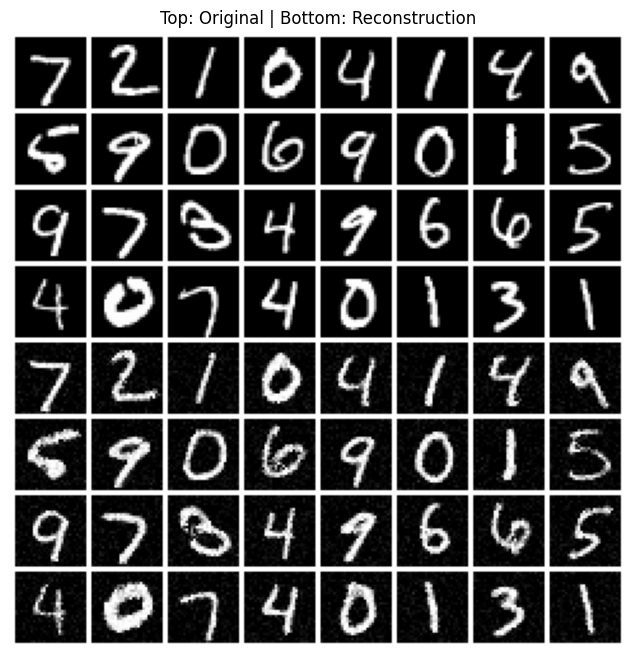

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3704467..1.983317].


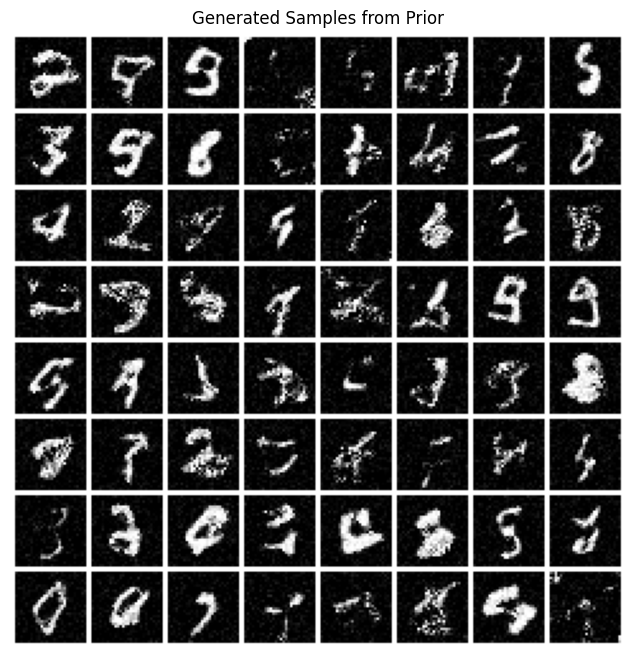

In [32]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 20
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_vae(model, train_loader, val_loader, optimizer, num_epochs=100, patience=10, device=device)
test_vae_reconstruction_and_generation(model, test_loader, device=device)
generate_from_prior(model, num_samples=64, device=device)

Save this model for tasks 3 and 4

In [33]:
model_20=model

Task 2

In [7]:


# ----------------------------
# Encoder Network
# ----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 7x7 -> 7x7 (added)
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# ----------------------------
# Decoder Network (Using Beta)
# ----------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv_base = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        self.alpha_head = nn.Conv2d(32, 1, kernel_size=3, padding=1)
        self.beta_head = nn.Conv2d(32, 1, kernel_size=3, padding=1)

    def forward(self, z):
        x = self.fc(z).view(-1, 64, 7, 7)
        x = self.deconv_base(x)
        alpha = F.softplus(self.alpha_head(x)) + 1e-3  
        beta = F.softplus(self.beta_head(x)) + 1e-3
        return alpha, beta

# ----------------------------
# VAE Wrapper
# ----------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu_z, logvar_z = self.encoder(x)
        z = self.reparameterize(mu_z, logvar_z)
        alpha, beta = self.decoder(z)
        return alpha, beta, mu_z, logvar_z, z

In [8]:


def get_mnist_dataloaders(batch_size=128):
    def transform_fn(x):
        x = transforms.ToTensor()(x)
        return (x * 0.98 + 0.01)  # now in [0.01, 0.99]
    
    full_train_set = datasets.MNIST('./data', train=True, download=True, transform=transform_fn)
    test_set = datasets.MNIST('./data', train=False, download=True, transform=transform_fn)
    train_set, val_set = random_split(full_train_set, [50000, 10000])
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True),
        DataLoader(val_set, batch_size=batch_size, shuffle=False),
        DataLoader(test_set, batch_size=batch_size, shuffle=False)
    )

def elbo_loss(x, alpha, beta, mu_z, logvar_z, beta_kl):
    B = x.size(0)
    x = x.view(B, -1)
    alpha = alpha.view(B, -1)
    beta = beta.view(B, -1)

    eps = 1e-6
    x = torch.clamp(x, eps, 1 - eps)

    log_likelihood = (
        torch.lgamma(alpha + beta)
        - torch.lgamma(alpha)
        - torch.lgamma(beta)
        + (alpha - 1) * torch.log(x)
        + (beta - 1) * torch.log(1 - x)
    )
    recon_loss = -torch.sum(log_likelihood, dim=1)

    kl_div = -0.5 * torch.sum(1 + logvar_z - mu_z.pow(2) - logvar_z.exp(), dim=1)

    return torch.mean(recon_loss + beta_kl * kl_div)

In [9]:

def train_vae(model, train_loader, val_loader, optimizer,
                                   num_epochs=100, patience=10, device='cuda'):

    model = model.to(device)
    train_elbo, val_elbo = [], []

    best_val_elbo = float('-inf')
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        #beta_kl = min(10.0, epoch / 50 * 10)
        beta_kl = 10

        model.train()
        total_train_loss = 0
        for x_batch, _ in train_loader:
            x_batch = x_batch.to(device)
            optimizer.zero_grad()
            mu_x, logvar_x, mu_z, logvar_z, _ = model(x_batch)
            loss = elbo_loss(x_batch, mu_x, logvar_x, mu_z, logvar_z, beta_kl)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_elbo.append(-avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for x_val, _ in val_loader:
                x_val = x_val.to(device)
                mu_x, logvar_x, mu_z, logvar_z, _ = model(x_val)
                loss = elbo_loss(x_val, mu_x, logvar_x, mu_z, logvar_z, beta_kl)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_elbo.append(-avg_val_loss)
        

        print(f"Epoch {epoch:02d} | Train ELBO: {-avg_train_loss:.4f} | Val ELBO: {-avg_val_loss:.4f}")

        # Early stopping logic
        if -avg_val_loss > best_val_elbo:
            best_val_elbo = -avg_val_loss
            epochs_without_improvement = 0
            best_model_state = model.state_dict()
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Stopping early at epoch {epoch} due to no improvement in validation ELBO.")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Plot ELBO
    plt.plot(train_elbo, label='Train ELBO')
    plt.plot(val_elbo, label='Validation ELBO')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO')
    plt.legend()
    plt.title('ELBO vs Epoch')
    plt.show()

    return train_elbo, val_elbo

In [10]:

def test_vae_reconstruction_and_generation(model, test_loader, device='cuda'):
    model.eval()
    model = model.to(device)

    # Get a single batch from test set
    x_test, _ = next(iter(test_loader))
    x_test = x_test[:32].to(device)  # use only first 32 for display
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x_test)
        z = model.reparameterize(mu_z, logvar_z)
        alpha, beta = model.decoder(z)
        alpha = torch.clamp(alpha, min=1e-3)
        beta = torch.clamp(beta, min=1e-3)
        recon_x = torch.distributions.Beta(alpha, beta).sample()

    # Arrange originals and reconstructions side-by-side
    grid = torch.cat([x_test.cpu(), recon_x.cpu()], dim=0)
    grid_img = vutils.make_grid(grid, nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Top: Original | Bottom: Reconstruction')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

def generate_from_prior(model, num_samples=64, device='cuda'):
    model.eval()
    model = model.to(device)

    with torch.no_grad():
        z = torch.randn(num_samples, model.encoder.fc_mu.out_features).to(device)
        alpha, beta = model.decoder(z)
        # alpha = torch.clamp(alpha, min=1e-3)
        # beta = torch.clamp(beta, min=1e-3)
        gen_x = torch.distributions.Beta(alpha, beta).sample()


    grid_img = vutils.make_grid(gen_x.cpu(), nrow=8, pad_value=1)

    plt.figure(figsize=(8, 8))
    plt.axis('off')
    plt.title('Generated Samples from Prior')
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 5630548.52it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 209755.15it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1487785.36it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<?, ?it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Epoch 01 | Train ELBO: 1893.9685 | Val ELBO: 2557.8621
Epoch 02 | Train ELBO: 2818.6277 | Val ELBO: 3033.2064
Epoch 03 | Train ELBO: 3146.1144 | Val ELBO: 3279.5970
Epoch 04 | Train ELBO: 3347.0983 | Val ELBO: 3449.5118
Epoch 05 | Train ELBO: 3464.9522 | Val ELBO: 3562.4256
Epoch 06 | Train ELBO: 3583.9101 | Val ELBO: 3665.9640
Epoch 07 | Train ELBO: 3665.3356 | Val ELBO: 3721.1978
Epoch 08 | Train ELBO: 3739.7054 | Val ELBO: 3798.0233
Epoch 09 | Train ELBO: 3790.6795 | Val ELBO: 3832.5984
Epoch 10 | Train ELBO: 3825.0608 | Val ELBO: 3887.8925
Epoch 11 | Train ELBO: 3876.9093 | Val ELBO: 3930.1755
Epoch 12 | Train ELBO: 3836.1902 | Val ELBO: 3493.9105
Epoch 13 | Train ELBO: 3947.4657 | Val ELBO: 3945.7113
Epoch 14 | Train ELBO: 3972.7754 | Val ELBO: 4004.5744
Epoch 15 | Train ELBO: 3988.9006 | Val ELBO: 3995.2758
Epoch 16 | Train ELBO: 4004.6364 | Val ELBO: 4039.1125
Epoch 17 | Train ELBO: 4015.1099 | Val ELBO: 

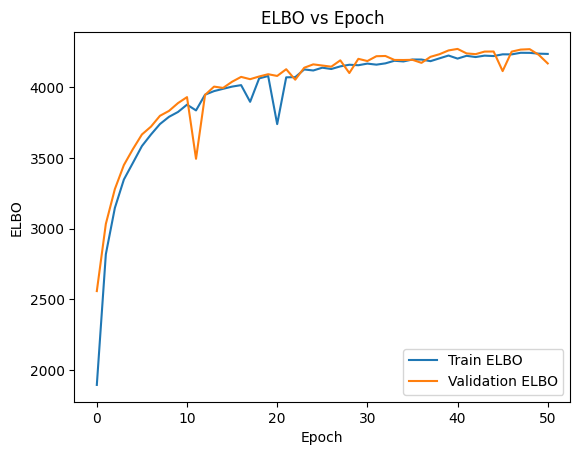

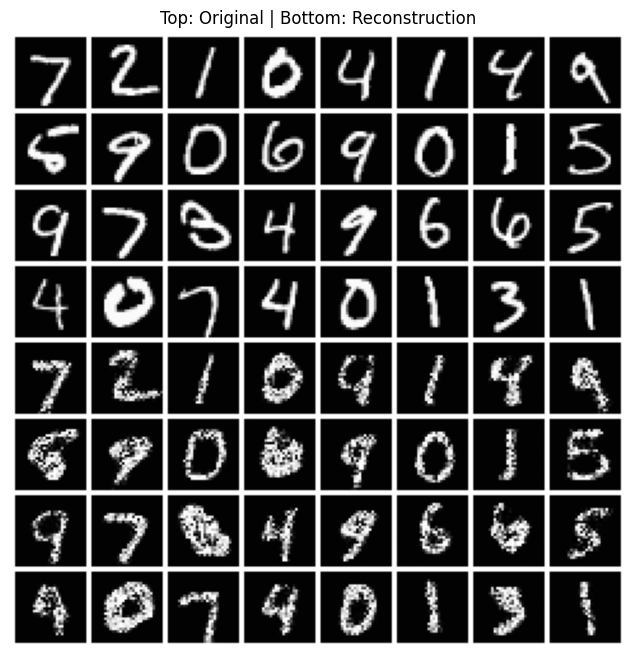

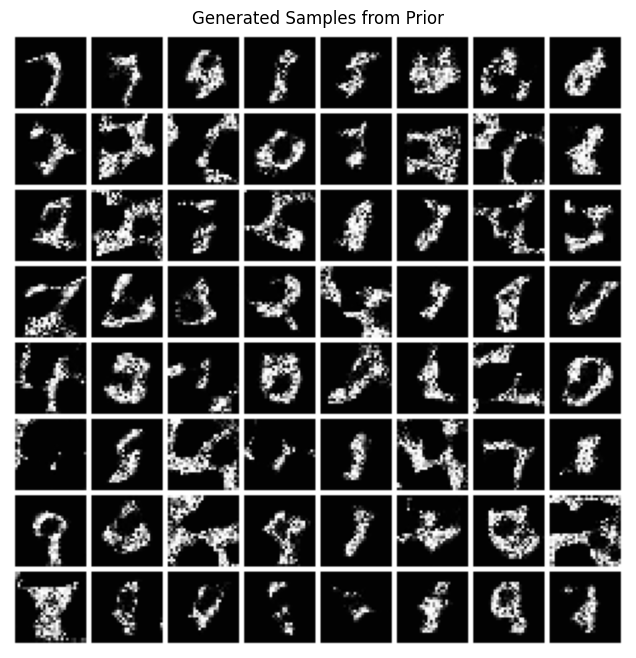

In [11]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 25
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_vae(model, train_loader, val_loader, optimizer, num_epochs=300, patience=10, device=device)
test_vae_reconstruction_and_generation(model, test_loader, device=device)
generate_from_prior(model, num_samples=64, device=device)

TASK 3

Epoch 01 | Train ELBO: 1212.8945 | Val ELBO: 1523.9760
Epoch 02 | Train ELBO: 1683.7521 | Val ELBO: 1804.2364
Epoch 03 | Train ELBO: 1885.6222 | Val ELBO: 1963.8553
Epoch 04 | Train ELBO: 2023.9367 | Val ELBO: 2078.5490
Epoch 05 | Train ELBO: 2127.8565 | Val ELBO: 2174.0693
Epoch 06 | Train ELBO: 2213.7363 | Val ELBO: 2253.6736
Epoch 07 | Train ELBO: 2285.9556 | Val ELBO: 2321.1794
Epoch 08 | Train ELBO: 2348.7407 | Val ELBO: 2379.7804
Epoch 09 | Train ELBO: 2404.0070 | Val ELBO: 2433.4301
Epoch 10 | Train ELBO: 2454.5626 | Val ELBO: 2481.5625
Epoch 11 | Train ELBO: 2499.0921 | Val ELBO: 2524.6195
Epoch 12 | Train ELBO: 2542.3005 | Val ELBO: 2552.7464
Epoch 13 | Train ELBO: 2578.9024 | Val ELBO: 2581.9152
Epoch 14 | Train ELBO: 2614.6600 | Val ELBO: 2634.6441
Epoch 15 | Train ELBO: 2646.4465 | Val ELBO: 2665.8216
Epoch 16 | Train ELBO: 2677.8773 | Val ELBO: 2685.4766
Epoch 17 | Train ELBO: 2703.9940 | Val ELBO: 2719.9124
Epoch 18 | Train ELBO: 2732.9780 | Val ELBO: 2742.0454
Epoch 19 |

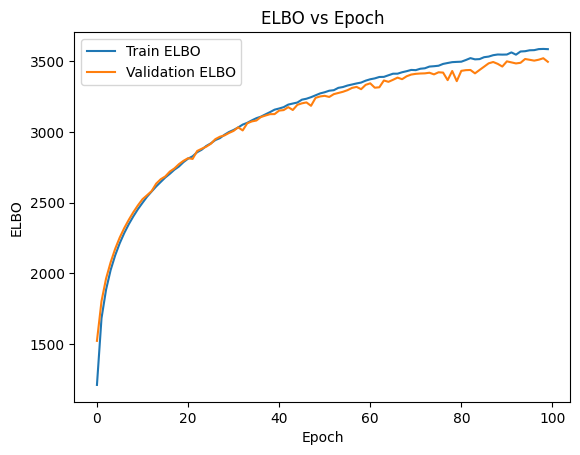

In [12]:
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 2
batch_size = 128

train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

train_elbo, val_elbo = train_vae(model, train_loader, val_loader, optimizer, device='cuda')

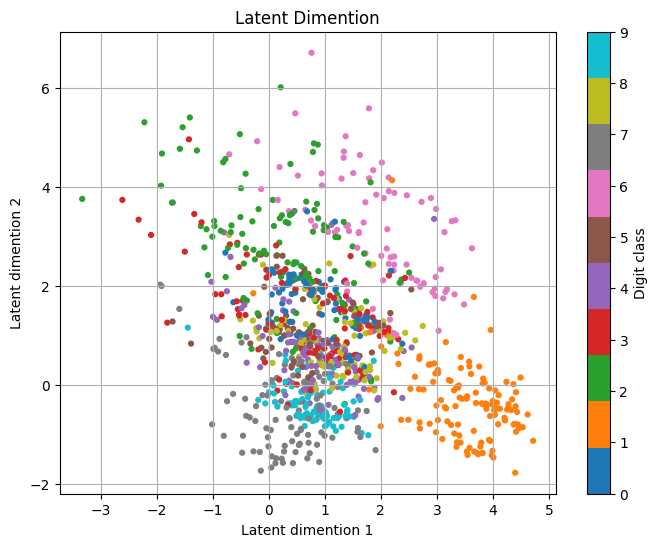

In [13]:
#model.load_state_dict(torch.load("vae_latent_2d.pth"))

def get_latents(model, test_loader, device, threshold = 1000):
    latent_var = []
    labels = []
    count = 0

    model = model.to(device)
    model.eval()
    
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        mu_z, _ = model.encoder(x_batch)
        latent_var.append(mu_z.detach().cpu().numpy())
        labels.append(y_batch.cpu().numpy())
        count += int(x_batch.size(0))
        if threshold <= count:
            break

    latents = np.vstack(latent_var)[:threshold]
    labels = np.hstack(labels)[:threshold]
    return latents, labels
    

def visualize(latents, labels, title_name, x_name, y_name):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(latents[:, 0], latents[:, 1], c = labels, cmap = 'tab10', s = 12)
    plt.colorbar(scatter, ticks=range(10), label='Digit class')
    plt.title(title_name)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.grid(True)
    plt.show()

latents,labels = get_latents(model, test_loader, device='cuda', threshold=1000)
visualize(latents, labels, "Latent Dimention", "Latent dimention 1", "Latent dimention 2")

Epoch 01 | Train ELBO: 1160.0733 | Val ELBO: 1476.7108
Epoch 02 | Train ELBO: 1767.8176 | Val ELBO: 1993.5553
Epoch 03 | Train ELBO: 2146.2465 | Val ELBO: 2276.2747
Epoch 04 | Train ELBO: 2376.8581 | Val ELBO: 2467.4946
Epoch 05 | Train ELBO: 2542.5092 | Val ELBO: 2611.9591
Epoch 06 | Train ELBO: 2672.9516 | Val ELBO: 2727.1084
Epoch 07 | Train ELBO: 2782.7742 | Val ELBO: 2825.7228
Epoch 08 | Train ELBO: 2876.0778 | Val ELBO: 2917.7491
Epoch 09 | Train ELBO: 2959.4473 | Val ELBO: 2995.0519
Epoch 10 | Train ELBO: 3036.9215 | Val ELBO: 3067.2574
Epoch 11 | Train ELBO: 3103.0012 | Val ELBO: 3135.0242
Epoch 12 | Train ELBO: 3165.9055 | Val ELBO: 3190.7392
Epoch 13 | Train ELBO: 3222.7686 | Val ELBO: 3240.6297
Epoch 14 | Train ELBO: 3275.8345 | Val ELBO: 3298.6014
Epoch 15 | Train ELBO: 3324.8426 | Val ELBO: 3347.7035
Epoch 16 | Train ELBO: 3371.8761 | Val ELBO: 3385.8044
Epoch 17 | Train ELBO: 3413.0825 | Val ELBO: 3434.0792
Epoch 18 | Train ELBO: 3450.5280 | Val ELBO: 3472.8243
Epoch 19 |

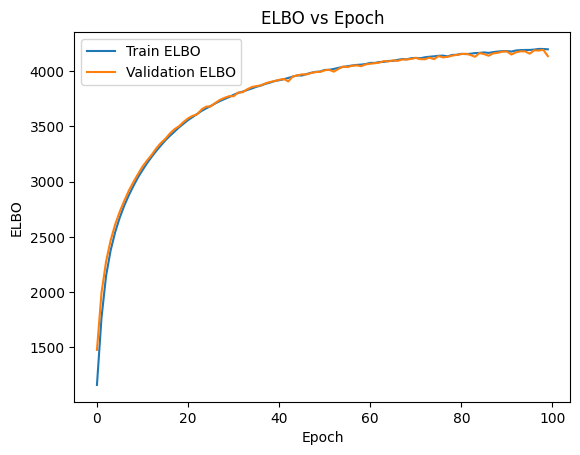

In [14]:
latent_dim = 10
train_loader, val_loader, test_loader = get_mnist_dataloaders(batch_size)

model_10 = VAE(latent_dim)
optimizer = torch.optim.Adam(model_10.parameters(), lr=1e-4)

train_elbo, val_elbo = train_vae(model_10, train_loader, val_loader, optimizer, device='cuda')

Shape of matrix U: (1000, 10)


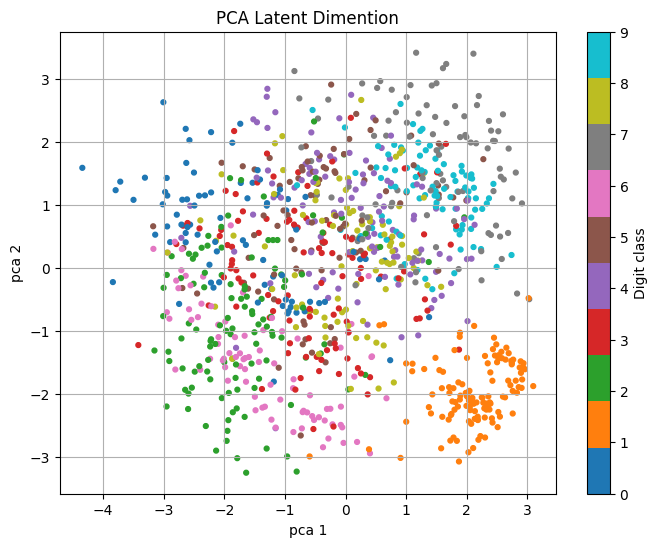

In [15]:
U, labels = get_latents(model_10, test_loader, device=device, threshold=1000)
print(f"Shape of matrix U: {U.shape}")

## PCA analysis on matrix U
pca = PCA(n_components=2)
U_pca = pca.fit_transform(U)

visualize(U_pca, labels, "PCA Latent Dimention", "pca 1", "pca 2")

In [17]:
# Sampling z from q(Z|x)
def random_latent_sample(model, x, device='cuda'):
    model.eval()
    model = model.to(device)
    x = x.to(device)
    with torch.no_grad():
        mu_z, logvar_z = model.encoder(x.unsqueeze(0))
        std_z = torch.exp(0.5 * logvar_z)
        eps = torch.randn_like(std_z)
        z = mu_z + eps * std_z
    return z.squeeze(0)

# Decoding z into x
def decode_latent(model, z, device='cuda'):
    model.eval()
    with torch.no_grad():
        mu_x, logvar_x = model.decoder(z.unsqueeze(0))
    return mu_x.squeeze(0).cpu()

Task 3c

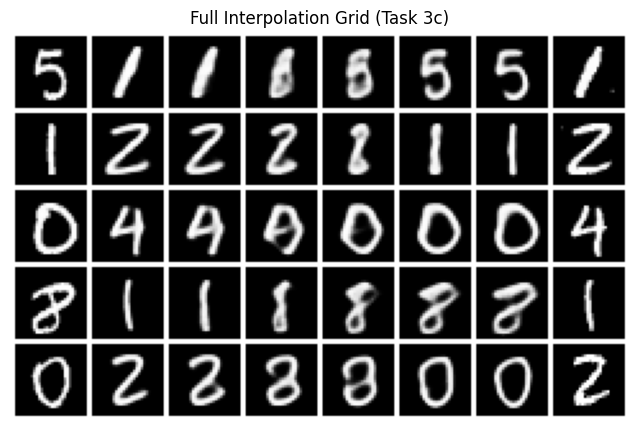

In [34]:


def compute_interpolation(model, test_loader, num_rows=5, num_steps=6, device='cuda'):
    lamdas = np.linspace(0, 1, num_steps)
    dataset = test_loader.dataset
    all_rows = []

    for _ in range(num_rows):
        while True:
            idx1 = random.randint(0, len(dataset)-1)
            idx2 = random.randint(0, len(dataset)-1)
            x1, y1 = dataset[idx1]
            x2, y2 = dataset[idx2]
            if y1 != y2:
                break

        z1 = random_latent_sample(model, x1, device=device)
        z2 = random_latent_sample(model, x2, device=device)

        row_images = []
        row_images.append(x1)  # add starting image

        for lamda in lamdas:
            linear_interpolation = lamda * z1 + (1 - lamda) * z2
            decode_z = decode_latent(model, linear_interpolation, device=device)
            row_images.append(decode_z)

        row_images.append(x2)  # add target image

        row_tensor = torch.stack([
            img if isinstance(img, torch.Tensor) else img.data for img in row_images
        ])
        all_rows.append(row_tensor)

    # Combine all rows into grid
    grid = torch.cat(all_rows, dim=0)
    grid_img = vutils.make_grid(grid, nrow=num_steps+2, pad_value=1)

    plt.figure(figsize=(num_steps+2, num_rows * 2))
    plt.axis('off')
    plt.title("Full Interpolation Grid (Task 3c)")
    plt.imshow(grid_img.permute(1, 2, 0), cmap='gray')
    plt.show()

compute_interpolation(model_20, test_loader,num_rows=5, num_steps=6, device=device)    

    
    
        

Task 4

In [22]:
class InferenceOptimizer(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(latent_dim))
        self.logvar = nn.Parameter(torch.zeros(latent_dim))

    def sample_z(self):
        std = torch.exp(0.5 * self.logvar)
        eps = torch.randn_like(std)
        return self.mu + eps * std

In [23]:
def elbo_single_point(x, decoder, infer_module, num_samples=5):
    elbo = 0
    for _ in range(num_samples):
        z = infer_module.sample_z()
        mu_x, logvar_x = decoder(z.unsqueeze(0))
        logvar_x = torch.clamp(logvar_x, min=-6.0, max=3.0)
        recon_loss = 0.5 * (logvar_x + ((x - mu_x) ** 2) / torch.exp(logvar_x)).sum()
        kl = -0.5 * torch.sum(1 + infer_module.logvar - infer_module.mu.pow(2) - infer_module.logvar.exp())
        elbo += recon_loss + kl
    return elbo / num_samples


In [24]:
def optimize_inference(x, decoder, latent_dim, lr=1e-2, max_steps=2000, patience=100, tol=1e-4, num_samples=1):
    infer = InferenceOptimizer(latent_dim).to(x.device)
    optimizer = torch.optim.Adam(infer.parameters(), lr=lr)

    best_loss = float("inf")
    patience_counter = 0

    for step in range(max_steps):
        optimizer.zero_grad()
        loss = elbo_single_point(x, decoder, infer, num_samples=num_samples)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss - tol:
            best_loss = loss.item()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return infer



We use an early stopping criterion based on validation of the ELBO loss. At each optimization step, we track the best ELBO obtained so far. If no significant improvement (greater than 1e-4) is observed for 100 consecutive steps, we terminate the optimization. We also impose a hard cap of 2000 steps.

We also experimented with using multiple Monte Carlo samples to estimate the expectation. This resulted in a huge increase in model performance.



In [25]:
def compare_reconstructions(model, test_loader, latent_dim, device='cuda',num_samples=1):
    model.eval()
    data_iter = iter(test_loader)
    images, _ = next(data_iter)
    images = images[:5].to(device)

    fig, axes = plt.subplots(len(images), 3, figsize=(9, len(images) * 2))
    for i, x in enumerate(images):
        infer = optimize_inference(x, model.decoder, latent_dim,num_samples=num_samples)
        z_opt = infer.sample_z().unsqueeze(0)
        mu_x_opt, logvar_x_opt = model.decoder(z_opt)
        std_x_opt = torch.exp(0.5 * logvar_x_opt)
        recon_opt = mu_x_opt + std_x_opt * torch.randn_like(std_x_opt)

        with torch.no_grad():
            mu_z, logvar_z = model.encoder(x.unsqueeze(0))
            z = model.reparameterize(mu_z, logvar_z)
            mu_x_std, logvar_x_std = model.decoder(z)
            std_x_std = torch.exp(0.5 * logvar_x_std)
            recon_std = mu_x_std + std_x_std * torch.randn_like(std_x_std)

        axes[i, 0].imshow(x.squeeze().cpu(), cmap='gray')
        axes[i, 0].set_title('Original')
        axes[i, 1].imshow(recon_opt.squeeze().detach().cpu(), cmap='gray')
        axes[i, 1].set_title('Optimized')
        axes[i, 2].imshow(recon_std.squeeze().detach().cpu(), cmap='gray')
        axes[i, 2].set_title('Encoder')

        for ax in axes[i]:
            ax.axis('off')
    plt.tight_layout()
    plt.show()

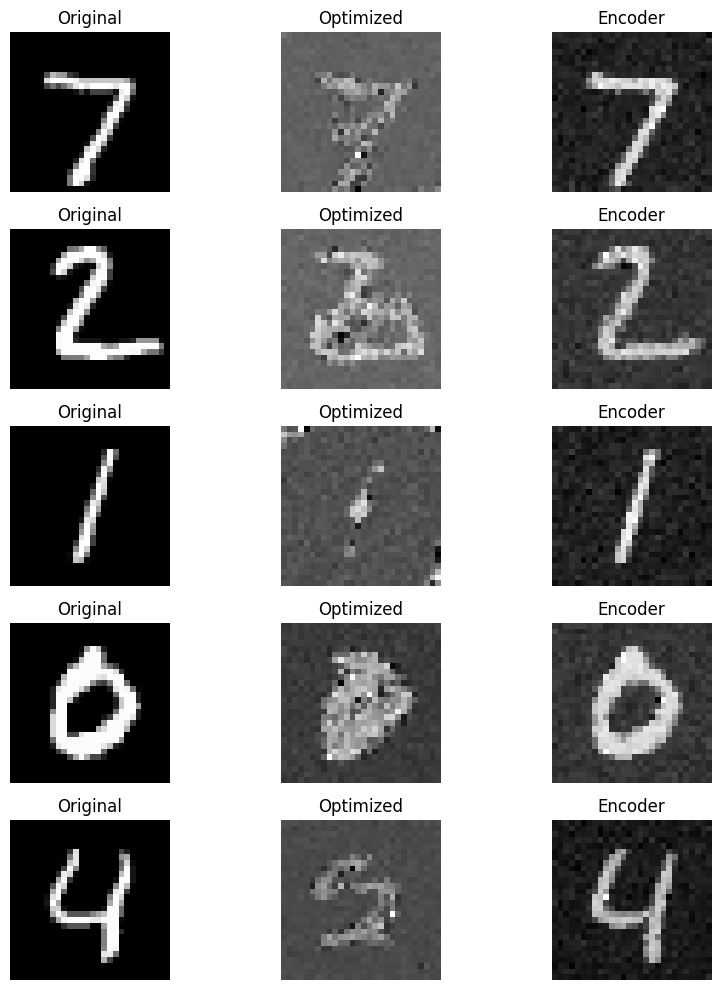

In [35]:
compare_reconstructions(model_20, test_loader, latent_dim=20, device=device)

Using multiple samples for the Monte Carlo estimate significantly improves the quality of the generated reconstructions.

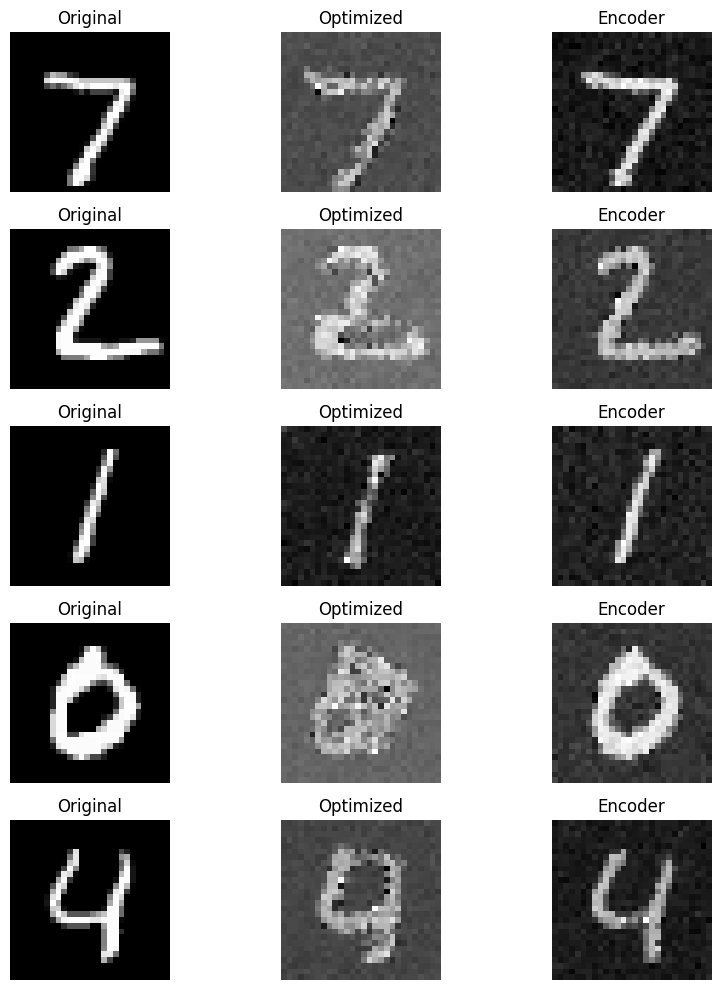

In [36]:
compare_reconstructions(model_20, test_loader, latent_dim=20, device=device,num_samples=5)

In [37]:
def elbo_left_half(x_left, decoder, infer_module, num_samples=1):
    elbo = 0
    for _ in range(num_samples):
        z = infer_module.sample_z()
        mu_x, logvar_x = decoder(z.unsqueeze(0))  
        logvar_x = torch.clamp(logvar_x, min=-6.0, max=3.0)
        mu_left = mu_x[:, :, :, :14]
        logvar_left = logvar_x[:, :, :, :14]

        recon_loss = 0.5 * (logvar_left + ((x_left.unsqueeze(0) - mu_left) ** 2) / torch.exp(logvar_left)).sum()
        kl = -0.5 * torch.sum(1 + infer_module.logvar - infer_module.mu.pow(2) - infer_module.logvar.exp())
        elbo += recon_loss + kl

    return elbo / num_samples



In [38]:
def optimize_inference_left(x, decoder, latent_dim, lr=1e-2, max_steps=2000, patience=100, tol=1e-4):
    infer = InferenceOptimizer(latent_dim).to(x.device)
    optimizer = torch.optim.Adam(infer.parameters(), lr=lr)

    x_left = x[:, :, :, :14]  
    best_loss = float("inf")
    patience_counter = 0

    for step in range(max_steps):
        optimizer.zero_grad()
        loss = elbo_left_half(x_left, decoder, infer, num_samples=5)
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss - tol:
            best_loss = loss.item()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return infer



We use an early stopping criterion based on validation of the ELBO loss. At each optimization step, we track the best ELBO obtained so far. If no significant improvement (greater than 1e-4) is observed for 100 consecutive steps, we terminate the optimization. We also impose a hard cap of 2000 steps.

In [39]:
def complete_images(model, test_loader, latent_dim, device='cuda'):
    model.eval()
    data_iter = iter(test_loader)
    images, _ = next(data_iter)
    images = images[:5].to(device)

    fig, axes = plt.subplots(len(images), 3, figsize=(9, len(images) * 2))

    for i, x in enumerate(images):
        x = x.unsqueeze(0)  

        infer = optimize_inference_left(x, model.decoder, latent_dim)
        z_opt = infer.sample_z().unsqueeze(0)
        mu_x, logvar_x = model.decoder(z_opt)
        std_x = torch.exp(0.5 * logvar_x)
        completed = mu_x + std_x * torch.randn_like(std_x)

        half_masked = torch.zeros_like(x)
        half_masked[:, :, :, :14] = x[:, :, :, :14]

        completed_combined = x.clone()
        completed_combined[:, :, :, 14:] = completed[:, :, :, 14:]

        axes[i, 0].imshow(x.squeeze().detach().cpu(), cmap='gray')
        axes[i, 0].set_title("Original")

        axes[i, 1].imshow(half_masked.squeeze().detach().cpu(), cmap='gray')
        axes[i, 1].set_title("Masked Left Only")

        axes[i, 2].imshow(completed_combined.squeeze().detach().cpu(), cmap='gray')
        axes[i, 2].set_title("Completed")

        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

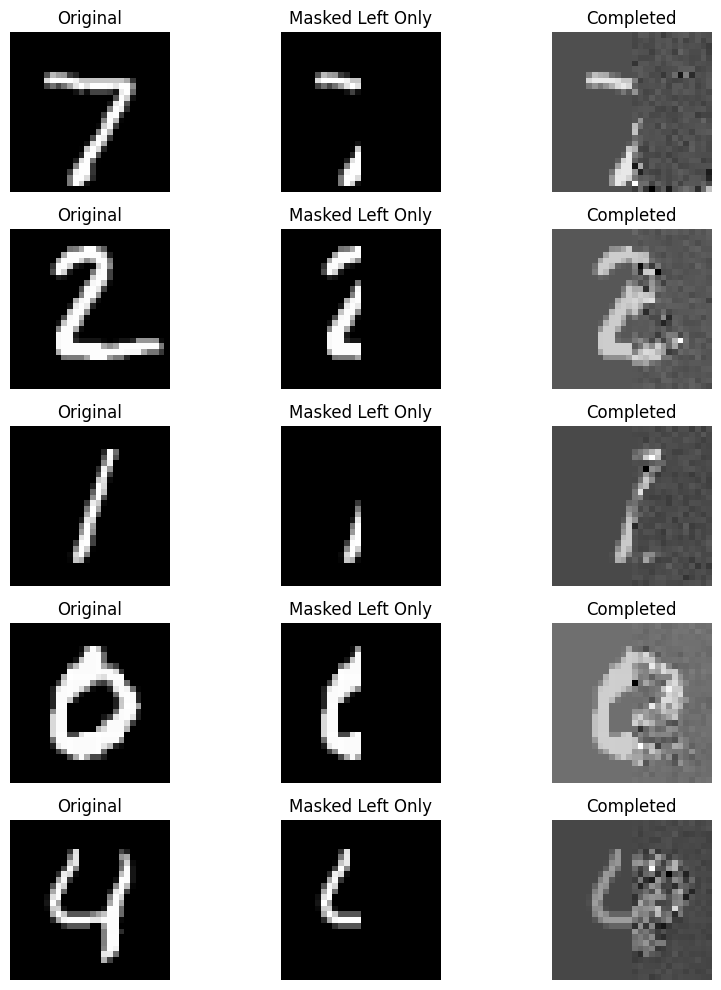

In [40]:
complete_images(model, test_loader, latent_dim=20, device=device)
